In [7]:
import slangpy
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os 
cwd = Path(os.getcwd())

device = slangpy.create_device(slangpy.DeviceType.vulkan)
program = (cwd / "GGXPrecompute.slang").as_posix()    

integrateGGX_E = device.create_compute_kernel(device.load_program(program, ["integrateGGX_E"]))    
integrateGGX_Eavg = device.create_compute_kernel(device.load_program(program, ["integrateGGX_Eavg"]))
integrateGGX_IOR_E = device.create_compute_kernel(device.load_program(program, ["integrateGGX_IOR_E"]))

ggx_E = device.create_buffer(element_count=32*32, struct_size=8, format=slangpy.Format.rg32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_Eavg = device.create_buffer(element_count=32, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_IOR_E = device.create_buffer(element_count=16*16*16, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)

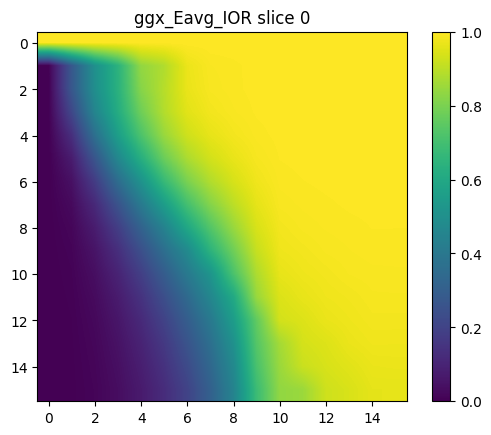

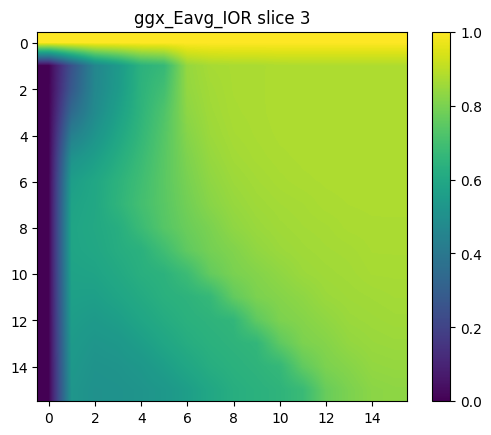

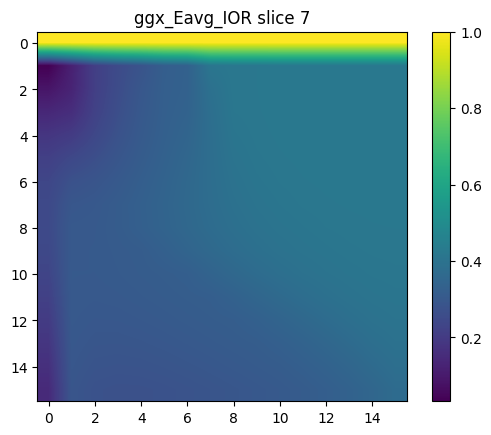

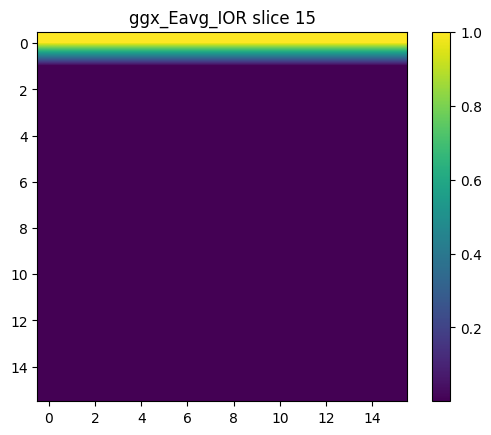

In [8]:
# Eavg IOR
integrateGGX_IOR_E.dispatch(thread_count=[1,1,16],vars={"ggxEIOR": ggx_IOR_E})
im_ggx_Eavg_IOR = ggx_IOR_E.to_numpy().reshape(16,16,16)
for slice in [0, 3, 7, 15]:
    plane = im_ggx_Eavg_IOR[slice,:,:]
    plt.imshow(plane, interpolation='bilinear')
    plt.title(f'ggx_Eavg_IOR slice {slice}')
    plt.colorbar()
    plt.show()


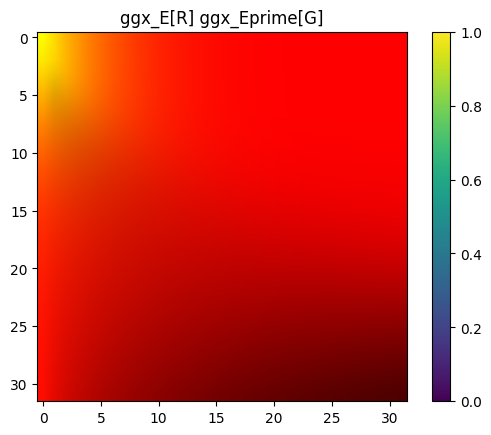

In [8]:
# E
integrateGGX_E.dispatch(thread_count=[1,1,1],vars={"ggxE": ggx_E})
im_ggx_E = ggx_E.to_numpy().reshape(32, 32, 2)
im_ggx_E = np.dstack([im_ggx_E, np.zeros((32, 32, 1), dtype=im_ggx_E.dtype)])
plt.imshow(im_ggx_E, interpolation='bilinear')
plt.title('ggx_E[R] ggx_Eprime[G]')
plt.colorbar()
plt.show()

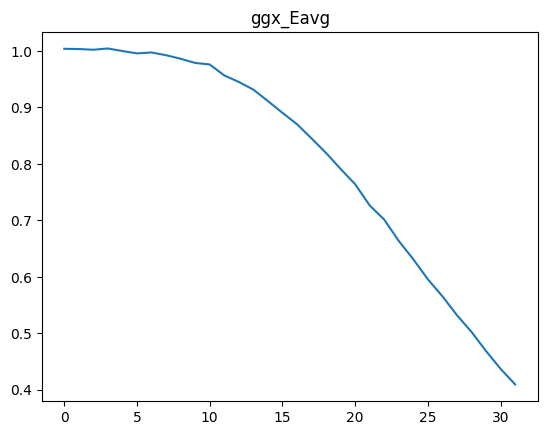

In [ ]:
# Eavg
integrateGGX_Eavg.dispatch(thread_count=[1,1,1],vars={"ggxEavg": ggx_Eavg})
im_ggx_Eavg = ggx_Eavg.to_numpy()
plt.plot(im_ggx_Eavg)
plt.title('ggx_Eavg')
plt.show()

In [ ]:
# Dump it.
# We don't use image containers for this as this would be uploaded back to GPU anyway
print("// Generated by Scripts/LUTPrecomputeGGX.ipynb")
print("constexpr float /* RG32 */ kGGXlutE[32 * 32 * 2] = {\n\t",end='')
for i, v in enumerate(ggx_E.to_numpy().flatten()):
    print(f"{v:.6f}f,", end=' ' if (i+1) % 32 else '\n\t')
print("\n};")

// Generated by Scripts/LUTPrecomputeGGX.ipynb
constexpr float /* RG32 */ kGGXlutE[32 * 32 * 2] = {
	0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f,
	0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f,
	0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.0000

In [ ]:
print("constexpr float /* R32 */ kGGXlutEavg[32] = {\n\t",end='')
for v in ggx_Eavg.to_numpy():
    print(f"{v:.6f}f,", end=' ')
print("\n};")

constexpr float /* R32 */ kGGXlutEavg[32] = {
	0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 
};
